# Class 5 - Geospatial Data (netCDF & xarray)

Recommended documentation: [Geospatial course from UGhent](https://github.com/plovercode/DS-python-geospatial/tree/main/notebooks)


Today we move from **time-series tabular data** (pandas, Class 4) to **multi-dimensional gridded data**.

Goals:
- understand what a netCDF file is and how to read it with  **xarray** ,
- select, slice, reduce, filter, resample gridded temperature data,
- apply value masks and geographic masks (e.g. keep only grid cells inside Freiburg city).

> **Scope of this course:** we mainly work with **raster / netCDF** data. For geographic masking we load one pre-prepared Boolean mask file (`freiburg_city_mask.nc`).

## 1. From pandas to xarray

In Class 4, each row was one time step and each column was one variable (temperature, humidity, …). That works well for a **point station**.

Gridded climate data has more axes at once, for example:

- **time** (hourly steps in January 2024),
- **latitude**,
- **longitude**,
- and one or more **data variables** (here: predicted temperature).

![xarray Dataset: data variables, coordinates, and attributes](img/xarray-dataset.png)

*Figure: an `xarray.Dataset` can hold several data variables that share coordinates (e.g. lon, lat, time), plus metadata in attributes. (Source: [xarray documentation](https://docs.xarray.dev/).)*


In [3]:
# Running this cell can take a few minutes
import matplotlib.pyplot as plt
import xarray as xr

## 2. Opening a netCDF with xarray

We use Future Forests **predicted 2 m air temperature** (`pred_temperature_C`) for January 2024 on a ~100 m grid provided by Christopher Jung.

The raw file is stored in projected coordinates (EPSG:25832, ETRS89 / UTM zone 32N). For class, we use a **preprocessed lon/lat (WGS84)** version:

In [1]:
ls ../processed_data/pred_temperature_C_2024_01_wgs84.nc

../processed_data/pred_temperature_C_2024_01_wgs84.nc


`xr.open_dataset` reads the file and returns a **Dataset**: a dictionary-like container of labelled arrays (DataArrays) that share dimensions.

In [ ]:
DataPath = "../processed_data/pred_temperature_C_2024_01_wgs84.nc"
# Lazy open: do not load the full ~3 GB grid into memory at once
TempDs = xr.open_dataset(DataPath, chunks="auto") # chunks="auto" open the files in chunks
print(TempDs)

<xarray.Dataset> Size: 11GB
Dimensions:             (time: 744, lat: 2132, lon: 1701)
Coordinates:
  * time                (time) datetime64[ns] 6kB 2024-01-01 ... 2024-01-31T2...
  * lat                 (lat) float64 17kB 49.65 49.65 49.65 ... 47.48 47.48
  * lon                 (lon) float64 14kB 7.311 7.312 7.313 ... 9.042 9.043
Data variables:
    pred_temperature_C  (time, lat, lon) float32 11GB dask.array<chunksize=(166, 474, 378), meta=np.ndarray>
    crs                 int64 8B ...
Attributes: (12/13)
    Conventions:            CF-1.8
    title:                  Predicted temperature on 100 m grid (reprojected ...
    source_file:            ["D:\\ERA5\\Future_Forests_Area\\d2m_C\\ERA5_2024...
    model_features:         ["Albedo_Albedo", "Albedo_Multiscale_Features_Alb...
    baseline_feature:       t2m_C
    baseline_scale_factor:  0.1
    ...                     ...
    institution:            Future Forests
    references:             LightGBM model application
    commen

On the output above we can observe:
1. There are 3 dimensions which are the 3 coordinates; `time` of size 744 (why?), `lat` of size 2132 and `lon` of size 1701.
2. There are two data variables, but only one is usuable (`crs` is for metadata): `pred_temperature_C` of shape `(time, lat, lon)`

Let's select the variable that interests us (there is only one variable in this file but there could be multiple):

In [6]:
Temp = TempDs["pred_temperature_C"]
print(Temp.dims)

('time', 'lat', 'lon')


`Temp` is a **`DataArray`**, an array of one variable (unlike the **`Dataset`**, which can hold several variables at once) with its own **dimension names** (`time`, `lat`, `lon`), **coordinate arrays** (`Temp.time`, `Temp.lat`, `Temp.lon`) and many other "**methods**" like `.dims`.

## 3. Selecting data

Similarly to `pandas`, there are two ways to select and slice data with `xarray`:

1. **`.isel(...)`** select by **integer position** (like NumPy indexing)

In [7]:
# Position-based: first time step
FirstMap = Temp.isel(time=0)

Quick map of the first time step with matplotlib. For a **2D grid** (lon × lat), use `plt.pcolormesh` to colour each cell

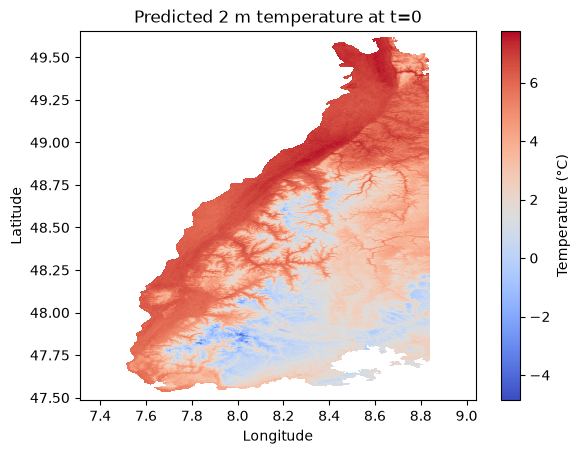

In [8]:
plt.pcolormesh(FirstMap.lon, FirstMap.lat, FirstMap, cmap="coolwarm", shading="auto")
# cmap = colormap (colour scale for the data values)
# shading = how the rectangular grid cells are rendered ("auto" infers it from lon/lat/data shapes)
# Always check the docs of each function you are using!
plt.colorbar(label="Temperature (°C)")
plt.title("Predicted 2 m temperature at t=0")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

- **`.sel(...)`** select by **coordinate label** (like pandas `.loc`)

In **Class 4** you worked with hourly data from the **Hartheim** climate station. We can extract the same location from the gridded map (~7.60°E, 47.93°N). The model grid will not contain that exact lon/lat pair, so we use `method="nearest"` to snap to the closest grid cell:

In [10]:
# Label-based: temperature near Hartheim station (~7.60°E, 47.93°N)
HartheimLon, HartheimLat = 7.60, 47.93
HartheimSeries = Temp.sel(lon=HartheimLon, lat=HartheimLat, method="nearest") # Nearest is used here for inexact matches

## Exercise A

Try to make a figure (which one will suit the most?) of `HartheimSeries`

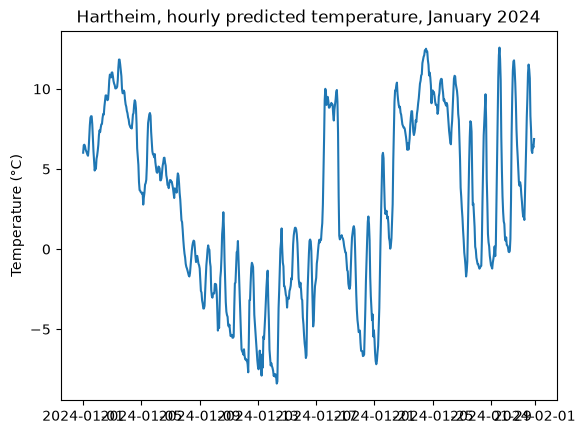

In [ ]:
# Solution
plt.plot(HartheimSeries.time, HartheimSeries)
plt.ylabel("Temperature (°C)")
plt.title("Hartheim, hourly predicted temperature, January 2024")
plt.show()

## 4. Slicing data

So far we selected a **single** time step (`.isel`) or a **single** grid point (`.sel` with `method="nearest"`). Often you want a **sub-region**: a box in lon/lat, or a time window.

Inside `.sel(...)`, pass Python's built-in `slice(start, stop)` for ranges, the same idea as `df.loc['2024-01-01':'2024-01-07']` in pandas:

- `slice(7.5, 8.1)` on `lon` keeps all cells between 7.5°E and 8.1°E
- `slice(48.15, 47.75)` on `lat` keeps all cells between 48.15°N and 47.75°N

The result is still a `DataArray`, but smaller: it keeps every time step inside the box.

Frozen({'time': 744, 'lat': 2132, 'lon': 1701})
Frozen({'time': 744, 'lat': 392, 'lon': 589})


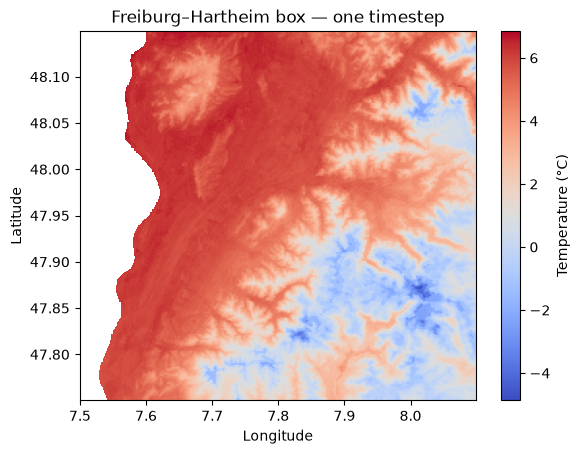

In [12]:
# Small box around Freiburg / Hartheim
print(Temp.sizes)
FreiburgBox = Temp.sel(
    lon=slice(7.5, 8.1),
    lat=slice(48.15, 47.75),  # high → low if lat decreases with index
)
print(FreiburgBox.sizes)

BoxMap = FreiburgBox.isel(time=0)

plt.pcolormesh(BoxMap.lon, BoxMap.lat, BoxMap, cmap="coolwarm", shading="auto")
plt.colorbar(label="Temperature (°C)")
plt.title("Freiburg–Hartheim box — one timestep")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

> **Note:** for latitude, values decrease north to south, this is not always the case.


## 5. Reduction

Let's say you want a map of the January temperature average. You have hourly values at every grid cell, so you need to collapse the time dimension and keep the spatial ones.

Reductions such as `.mean()`, `.min()`, `.max()` can run along one dimension. It is the same idea as pandas aggregations, but you name the axis explicitly.

In [13]:
JanMeanMap = Temp.mean(dim="time")
print(JanMeanMap.dims)

('lat', 'lon')


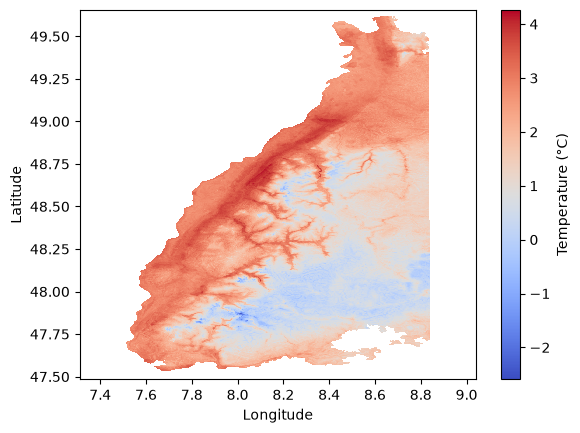

In [14]:
plt.pcolormesh(JanMeanMap.lon, JanMeanMap.lat, JanMeanMap, cmap="coolwarm", shading="auto")
plt.colorbar(label="Temperature (°C)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Now ask how the region as a whole evolved during January. This time you collapse lat and lon and keep time, which leaves you with a single time series instead of a map.

In [15]:
# Spatial mean over the Freiburg box → one value per time
BoxSpatialMean = FreiburgBox.mean(dim=("lat", "lon"))
print(BoxSpatialMean.dims)

('time',)


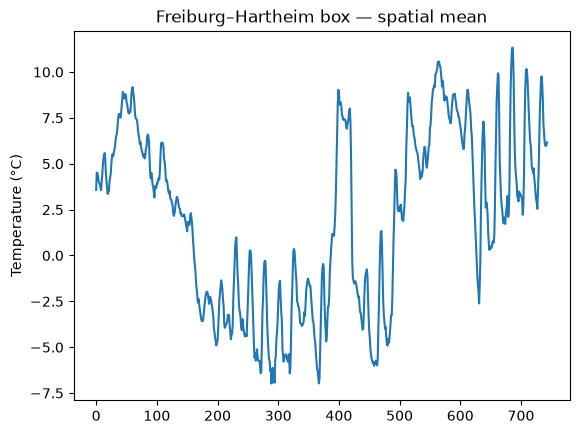

In [16]:
plt.plot(BoxSpatialMean)
plt.ylabel("Temperature (°C)")
plt.title("Freiburg–Hartheim box — spatial mean")
plt.show()

## Exercise B

Similarly to what we have done above, try to reduce the right dimension to make a zonal mean (or latitudinal) plot with `FreiburgBox`

('lat',)


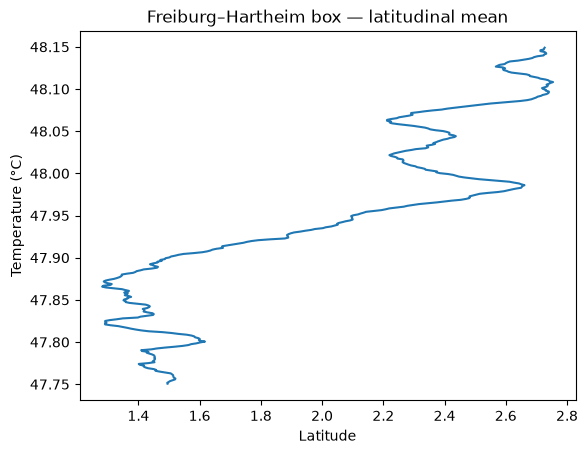

In [18]:
# Solution
BoxLatitudinalMean = FreiburgBox.mean(dim=("lon", "time"))
print(BoxLatitudinalMean.dims)

plt.plot(BoxLatitudinalMean, BoxLatitudinalMean.lat)
plt.xlabel("Latitude")
plt.ylabel("Temperature (°C)")
plt.title("Freiburg–Hartheim box — latitudinal mean")
plt.show()

## 6. Changing time resolution (`resample`)

In **Class 4**, you used `.resample('D').mean()` on the Hartheim station table to go from hourly to daily values. `xarray` does the same on gridded data: group timestamps into coarser bins, then aggregate, e.g. **`resample(time="1D")`:** calendar-day bins (then `.mean()`, `.sum()`, …)

The frequency strings differ slightly from pandas (`"1D"` vs `"D"`), but the idea is unchanged: **change the time resolution, then reduce**.


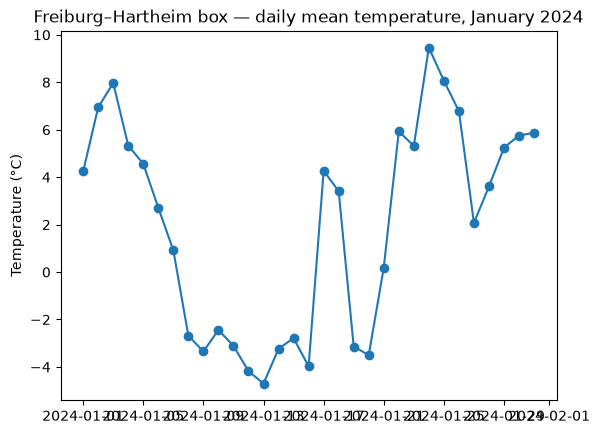

In [28]:
# Daily means: spatial mean over the box, then change time resolution
BoxSeries = FreiburgBox.mean(dim=("lat", "lon"))
Daily = BoxSeries.resample(time="1D").mean()

plt.plot(Daily.time, Daily, marker="o")
plt.ylabel("Temperature (°C)")
plt.title("Freiburg–Hartheim box — daily mean temperature, January 2024")
plt.show()

## 7. Filtering / masking with `.where`

In **Class 3b**, you filtered NumPy arrays with a Boolean mask, e.g. `TempC[TempC > 21.0]`. That keeps only the matching values and **shrinks** the array.

When you need the **same shape** as the input, for example to plot a map where rejected cells are blank, you used `np.where(condition, value_if_true, np.nan)`.

xarray's `.where(condition)` does the same thing on a `DataArray`: it keeps values where the condition is `True` and sets the rest to `NaN` (grid shape unchanged — useful for maps).


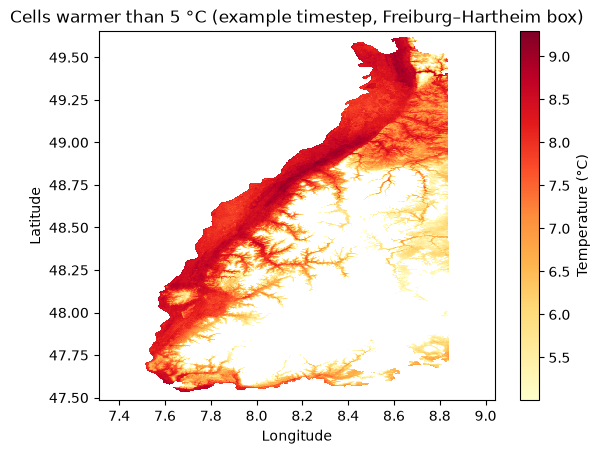

In [19]:
WarmCells = Temp.where(Temp > 5)
WarmMap = WarmCells.isel(time=12)

plt.pcolormesh(WarmMap.lon, WarmMap.lat, WarmMap, cmap="YlOrRd", shading="auto")
plt.colorbar(label="Temperature (°C)")
plt.title("Cells warmer than 5 °C (example timestep, Freiburg–Hartheim box)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### Geographic masks

The example above used a **value mask** (`Temp > 5`): a field of `True`/`False` values, like the Boolean masks in **Class 4**.

You can also mask by **location**. For Freiburg city, we prepared a Boolean mask on the same lon/lat grid (`freiburg_city_mask.nc` in `processed_data/`, built from the OpenStreetMap city boundary). Load it with `xr.open_dataarray`, then pass it to `.where(...)` — same pattern as before, but the condition comes from a file instead of `Temp > 5`.

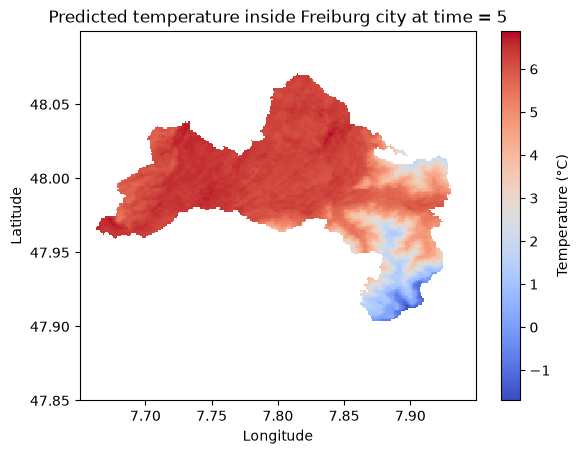

In [27]:
InFreiburg = xr.open_dataarray("../processed_data/freiburg_city_mask.nc")

# Zoom in on the city
LocalBox = Temp.sel(lon=slice(7.65, 7.95), lat=slice(48.1, 47.85))

# Masking
LocalBoxMasked = LocalBox.where(InFreiburg)

# Select time-step
CityMap = LocalBoxMasked.isel(time=5)

plt.pcolormesh(CityMap.lon, CityMap.lat, CityMap, cmap="coolwarm", shading="auto")
plt.colorbar(label="Temperature (°C)")
plt.title("Predicted temperature inside Freiburg city at time = 5")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## Exercise C

Foresters are going to cut trees on a specific region (`lon=7.5–8.1`, `lat=48.15→47.75`), on a specific date (`2024-01-20T14:00`). They ask you to make a map of the area that are frozen (where they cannot use their tools).

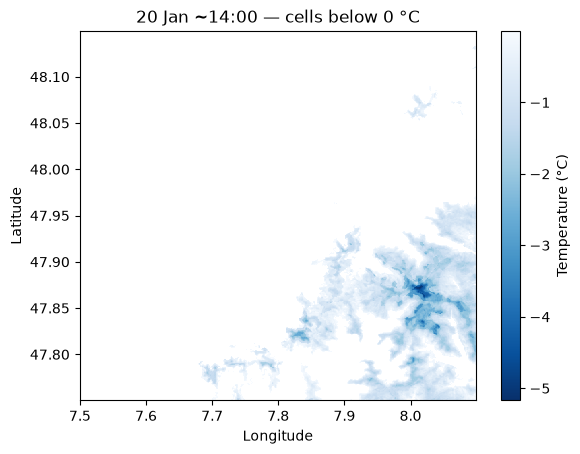

In [36]:
# Solution
CollectWoodDate = Temp.sel(lon=slice(7.5, 8.1), lat=slice(48.15, 47.75)).sel(
    time="2024-01-20T14:00", method="nearest"
)
BelowZero = CollectWoodDate.where(CollectWoodDate < 0)

plt.pcolormesh(BelowZero.lon, BelowZero.lat, BelowZero, cmap="Blues_r", shading="auto")
plt.colorbar(label="Temperature (°C)")
plt.title("20 Jan ~14:00 — cells below 0 °C")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
